# Model Evaluation

This notebook evaluates the machine learning models developed
for crop yield prediction.

The models evaluated are:
- Random Forest
- XGBoost
- Support Vector Regression (SVR)

The evaluation metrics used are:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Actual-versus-Predicted plots and residual analysis are also
performed for the models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    r"C:\Crop Yield Prediction\data\Crop Yield Data.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (19689, 13)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [3]:
print("========== MISSING VALUE ANALYSIS ==========")

print(df.isnull().sum())

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

========== MISSING VALUE ANALYSIS ==========
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    2
Fertilizer         2
Pesticide          2
Yield              1
Avg_Temperature    2
Max_Temperature    0
Min_Temperature    0
dtype: int64

Total missing values: 9


In [4]:
print("========== MISSING VALUE ANALYSIS ==========")

print(df.isnull().sum())

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

========== MISSING VALUE ANALYSIS ==========
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    2
Fertilizer         2
Pesticide          2
Yield              1
Avg_Temperature    2
Max_Temperature    0
Min_Temperature    0
dtype: int64

Total missing values: 9


In [12]:
print(
    "Missing Yield values before removal:",
    df["Yield"].isnull().sum()
)

df = df.dropna(
    subset=["Yield"]
).reset_index(drop=True)

print(
    "Missing Yield values after removal:",
    df["Yield"].isnull().sum()
)

print(
    "Dataset shape after removing missing Yield:",
    df.shape
)

Missing Yield values before removal: 0
Missing Yield values after removal: 0
Dataset shape after removing missing Yield: (19688, 13)


In [13]:
X = df.drop(["Yield", "Production"], axis=1)
y = df["Yield"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (19688, 11)
Target shape: (19688,)


## Feature Selection

The target variable is `Yield`.

The `Production` feature is excluded because it is directly
related to crop yield and may introduce target leakage.

Therefore, `Production` is not used as a model input.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15750, 11)
Testing data: (3938, 11)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("========== TRAIN-TEST SPLIT ==========")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

========== TRAIN-TEST SPLIT ==========
Training data shape: (15750, 11)
Testing data shape: (3938, 11)
Training target shape: (15750,)
Testing target shape: (3938,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("========== TRAIN-TEST SPLIT ==========")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

========== TRAIN-TEST SPLIT ==========
Training data shape: (15750, 11)
Testing data shape: (3938, 11)
Training target shape: (15750,)
Testing target shape: (3938,)


In [20]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created!")

Numerical preprocessing pipeline created!


In [18]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created!")

Categorical preprocessing pipeline created!


In [22]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']

Categorical features:
['Crop', 'Season', 'State']


C:\Users\Manisha\AppData\Local\Temp\ipykernel_11064\1998881318.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [24]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Data preprocessing completed!")

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Data preprocessing completed!

Processed training shape: (15750, 99)
Processed testing shape: (3938, 99)


In [25]:
rf_model = joblib.load(
    r"C:\Crop Yield Prediction\models\random_forest_model.pkl"
)

rf_predictions = rf_model.predict(
    X_test_processed
)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [26]:
xgb_model = joblib.load(
    r"C:\Crop Yield Prediction\models\xgboost_model.pkl"
)

xgb_predictions = xgb_model.predict(
    X_test_processed
)

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [27]:
svr_model = joblib.load(
    r"C:\Crop Yield Prediction\models\svr_model.pkl"
)

svr_predictions = svr_model.predict(
    X_test_processed
)

print("SVR predictions generated!")

SVR predictions generated!


In [28]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("========== RANDOM FOREST ==========")

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

========== RANDOM FOREST ==========
MAE : 11.588271422041649
MSE : 23237.085144497356
RMSE: 152.43715145756744
R²  : 0.9671132070577182


In [29]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("========== XGBOOST ==========")

print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

========== XGBOOST ==========
MAE : 10.303998766511603
MSE : 15721.06440776284
RMSE: 125.38366882398537
R²  : 0.9777504197796166


In [30]:
svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_mse = mean_squared_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

print("========== SVR ==========")

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R²  :", svr_r2)

========== SVR ==========
MAE : 60.80751243054028
MSE : 553774.2173311898
RMSE: 744.1600750720169
R²  : 0.2162589279637923


In [31]:
svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_mse = mean_squared_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

print("========== SVR ==========")

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R²  :", svr_r2)

========== SVR ==========
MAE : 60.80751243054028
MSE : 553774.2173311898
RMSE: 744.1600750720169
R²  : 0.2162589279637923


In [32]:
evaluation_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "SVR"
    ],
    
    "MAE": [
        rf_mae,
        xgb_mae,
        svr_mae
    ],
    
    "MSE": [
        rf_mse,
        xgb_mse,
        svr_mse
    ],
    
    "RMSE": [
        rf_rmse,
        xgb_rmse,
        svr_rmse
    ],
    
    "R²": [
        rf_r2,
        xgb_r2,
        svr_r2
    ]
})

evaluation_results

,Model,MAE,MSE,RMSE,R²
0,Random Forest,11.588271,23237.085144,152.437151,0.967113
1,XGBoost,10.303999,15721.064408,125.383669,0.977750
2,SVR,60.807512,553774.217331,744.160075,0.216259


In [33]:
evaluation_results_rounded = evaluation_results.copy()

evaluation_results_rounded[
    ["MAE", "MSE", "RMSE", "R²"]
] = evaluation_results_rounded[
    ["MAE", "MSE", "RMSE", "R²"]
].round(4)

evaluation_results_rounded

,Model,MAE,MSE,RMSE,R²
0,Random Forest,11.5883,23237.0851,152.4372,0.9671
1,XGBoost,10.3040,15721.0644,125.3837,0.9778
2,SVR,60.8075,553774.2173,744.1601,0.2163


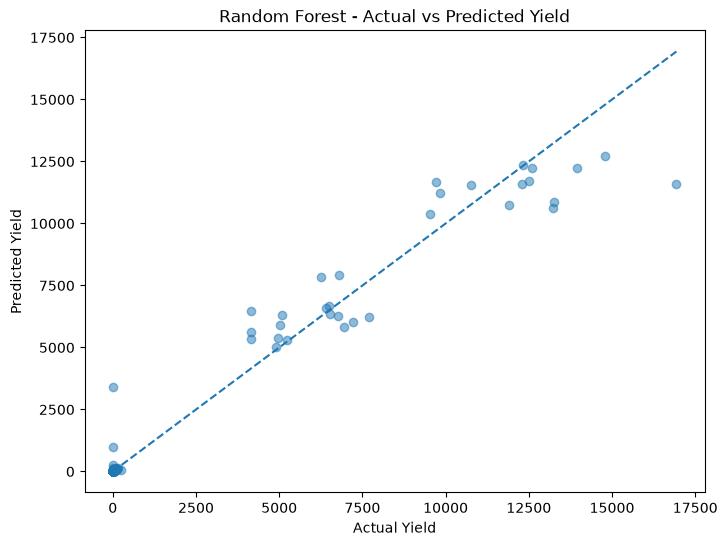

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Actual vs Predicted Yield")

plt.show()

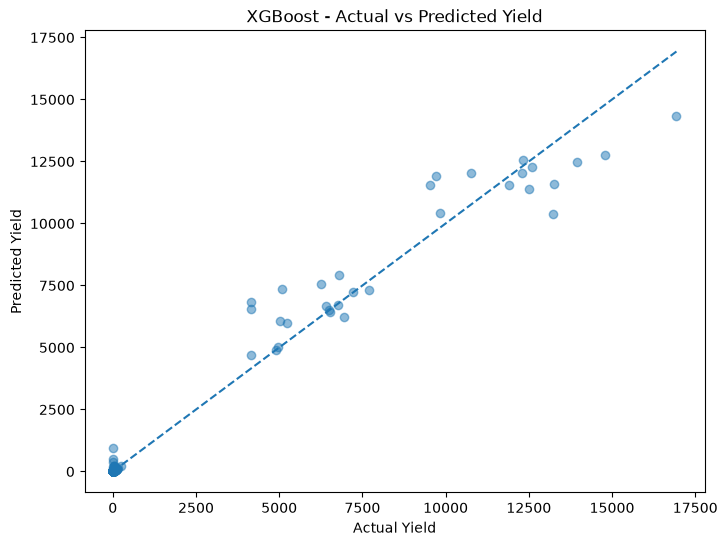

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    xgb_predictions.min()
)

max_value = max(
    y_test.max(),
    xgb_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost - Actual vs Predicted Yield")

plt.show()

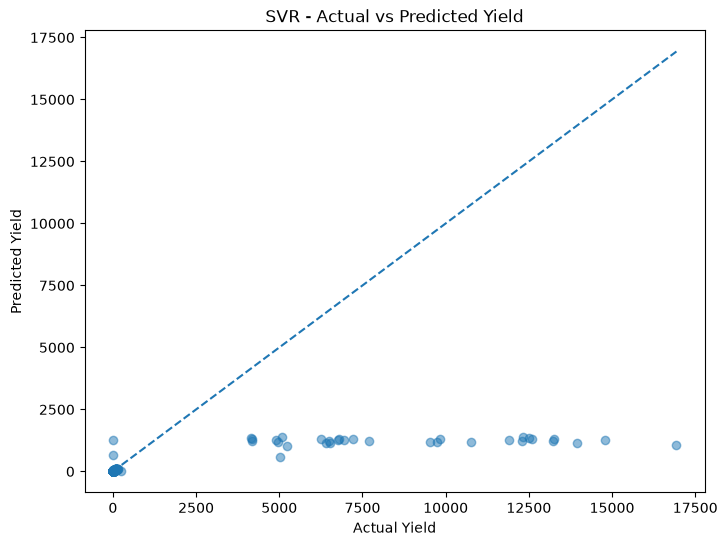

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    svr_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    svr_predictions.min()
)

max_value = max(
    y_test.max(),
    svr_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("SVR - Actual vs Predicted Yield")

plt.show()

In [37]:
rf_residuals = y_test - rf_predictions
xgb_residuals = y_test - xgb_predictions
svr_residuals = y_test - svr_predictions

print("Residuals calculated successfully!")

Residuals calculated successfully!


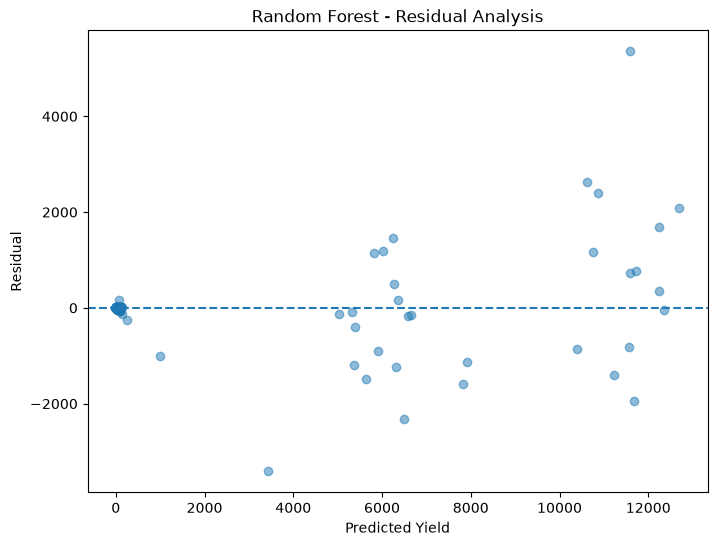

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("Random Forest - Residual Analysis")

plt.show()

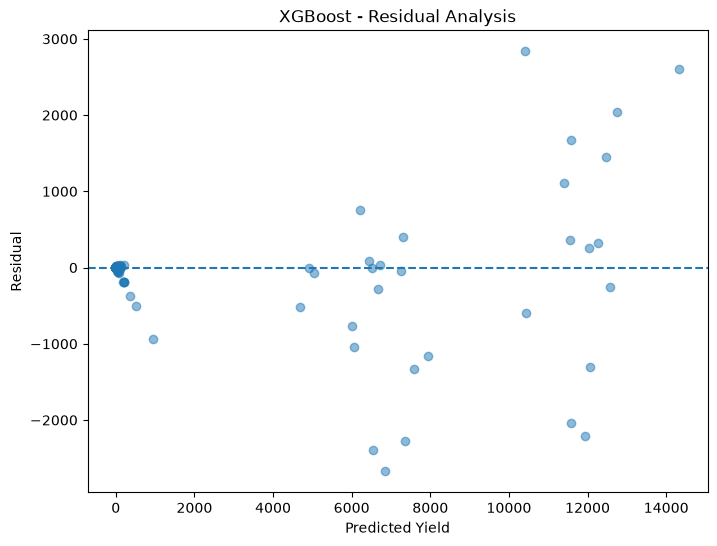

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_predictions,
    xgb_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("XGBoost - Residual Analysis")

plt.show()

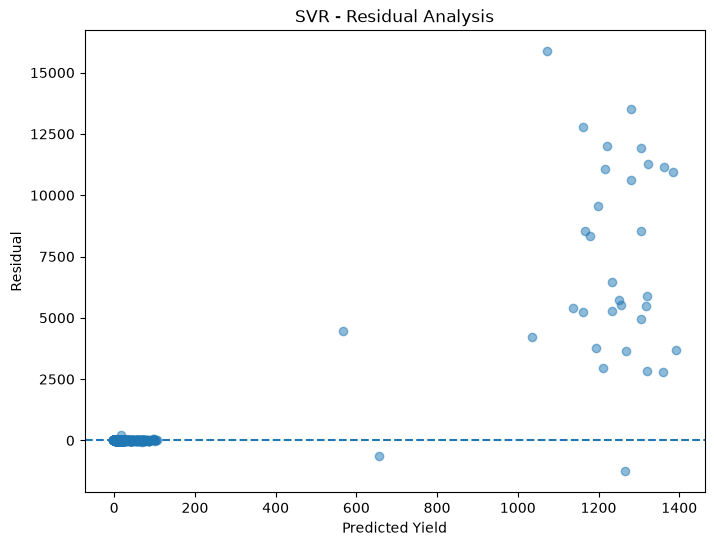

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    svr_predictions,
    svr_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("SVR - Residual Analysis")

plt.show()

In [41]:
print("========== RANDOM FOREST RESIDUALS ==========")
print(pd.Series(rf_residuals).describe())

print("\n========== XGBOOST RESIDUALS ==========")
print(pd.Series(xgb_residuals).describe())

print("\n========== SVR RESIDUALS ==========")
print(pd.Series(svr_residuals).describe())

========== RANDOM FOREST RESIDUALS ==========
count    3938.000000
mean        0.123890
std       152.456459
min     -3416.675530
25%        -0.162467
50%        -0.017265
75%         0.118010
max      5354.158890
Name: Yield, dtype: float64

========== XGBOOST RESIDUALS ==========
count    3938.000000
mean       -2.100685
std       125.381991
min     -2675.092594
25%        -0.644796
50%        -0.229615
75%         0.272127
max      2834.587133
Name: Yield, dtype: float64

========== SVR RESIDUALS ==========
count     3938.000000
mean        59.079807
std        741.905362
min      -1266.386573
25%         -0.176084
50%          0.001321
75%          0.169966
max      15861.789475
Name: Yield, dtype: float64


In [42]:
evaluation_results.to_csv(
    r"C:\Crop Yield Prediction\outputs\model_evaluation_results.csv",
    index=False
)

print("Model evaluation results saved successfully!")

Model evaluation results saved successfully!


## Evaluation Summary

The Random Forest, XGBoost and SVR models were evaluated
using the same test dataset.

The evaluation metrics used were:
- MAE
- MSE
- RMSE
- R²

Actual-versus-Predicted plots were generated to visually
compare predicted yield with actual yield.

Residual plots were generated to analyze prediction errors.

The evaluation results will be used in the next notebook
for detailed model comparison.